# Land Cover Classification for Sentinel-2 Image

This notebook performs unsupervised land cover classification using K-means clustering on Sentinel-2 imagery.

## What is Land Cover Classification?

Land cover classification categorizes pixels in satellite imagery into different land cover types based on their spectral characteristics. This notebook uses unsupervised K-means clustering to automatically identify common land cover classes:

- **Water**: Lakes, rivers, oceans
- **Vegetation**: Forests, crops, grasslands
- **Built-up**: Urban areas, buildings, roads
- **Bare soil**: Exposed soil, sand, rock
- **Other**: Additional classes based on spectral characteristics

## Parameters

This notebook has been automatically configured with the following parameters:

- **Collection**: {{STAC_COLLECTION_NAME}}
- **STAC Item**: {{STAC_ITEM_LINK}}
- **AOI (Area of Interest)**: {{AOI}} *(optional - if not provided, a 1000x1000 pixel sample will be used)*
- **Number of Classes**: {{NUM_CLASSES}} *(default: 5)*

## Workflow

1. Load the STAC item
2. Access multiple Sentinel-2 bands (Blue, Green, Red, NIR)
3. Calculate spectral indices (NDVI, NDWI)
4. Prepare features for classification
5. Perform K-means clustering
6. Automatically label classes based on spectral characteristics
7. Visualize the classification results

## Step 1: Import Required Libraries

In [1]:
import pystac
import rasterio
from rasterio.windows import Window
from rasterio.mask import mask
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Note: Install scikit-learn with: mamba install scikit-learn (or: pip install scikit-learn)
# The package is installed as 'scikit-learn' but imported as 'sklearn'
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import json
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


## Step 2: Determine Area of Interest (AOI)

Determine the area to process. If an AOI is provided, clip to that geometry. Otherwise, extract a 1000x1000 pixel sample from the center of the image.

In [2]:
# AOI parameter - must be GeoJSON geometry (Polygon, MultiPolygon, etc.)
aoi_param = "{{AOI}}".strip()

# Default window size if no AOI provided
DEFAULT_WINDOW_SIZE = 1000  # pixels

aoi_geometry = None
clip_window = None
use_windowed_read = False

# Check if AOI is provided
if aoi_param and aoi_param.lower() not in ["", "none", "null"]:
    try:
        # Parse as JSON
        aoi_data = json.loads(aoi_param)

        # Extract geometry from GeoJSON structure
        if aoi_data.get("type") == "FeatureCollection":
            # Extract first geometry from FeatureCollection
            if aoi_data.get("features") and len(aoi_data["features"]) > 0:
                aoi_geometry = aoi_data["features"][0].get("geometry")
        elif aoi_data.get("type") == "Feature":
            # Extract geometry from Feature
            aoi_geometry = aoi_data.get("geometry")
        elif aoi_data.get("type") in ["Polygon", "MultiPolygon", "Point", "LineString"]:
            # Direct geometry object
            aoi_geometry = aoi_data
        else:
            raise ValueError(f"Unsupported GeoJSON type: {aoi_data.get('type')}")

        # Validate geometry was extracted
        if aoi_geometry and aoi_geometry.get("type"):
            print(f"AOI provided: {aoi_geometry['type']} geometry")
            print("Will clip raster to AOI geometry")
        else:
            raise ValueError("Could not extract geometry from GeoJSON")

    except (json.JSONDecodeError, ValueError, KeyError) as e:
        print(f"Warning: Could not parse AOI as GeoJSON: {e}")
        print("Falling back to default 1000x1000 pixel window")
        aoi_geometry = None
else:
    print("No AOI provided, using default 1000x1000 pixel window")

# Set up windowed read if no AOI geometry
if aoi_geometry is None:
    use_windowed_read = True
    print(
        f"Will extract {DEFAULT_WINDOW_SIZE}x{DEFAULT_WINDOW_SIZE} pixel window from center"
    )

Falling back to default 1000x1000 pixel window
Will extract 1000x1000 pixel window from center


In [ ]:
# STAC item URL - automatically populated from selected dataset
stac_item_url = "{{STAC_ITEM_LINK}}"
stac_collection_name = "{{STAC_COLLECTION_NAME}}"

try:
    # Load the STAC item
    item = pystac.Item.from_file(stac_item_url)

    print(f"Successfully loaded STAC item: {item.id}")
    print(f"Collection: {stac_collection_name}")
    print(f"Date: {item.datetime}")
    print(f"Geometry: {item.geometry}")

except Exception as e:
    print(f"Error loading STAC item: {e}")
    raise

Successfully loaded STAC item: neodc.sentinel_ard.data.sentinel_2.2026.01.10.S2B_20260110_latn527lonw0007_T30UXD_ORB137_20260110130458_utm30n_osgb
Collection: sentinel2_ard
Date: 2026-01-10 11:13:39+00:00
Geometry: {'type': 'Polygon', 'coordinates': [[[-1.501539571659072, 53.24020834947074], [0.141769904481162, 53.20820137275637], [0.071678487044592, 52.22256603361336], [-1.535019632835204, 52.25345680664421], [-1.501539571659072, 53.24020834947074]]]}


## Step 3: Access Sentinel-2 Bands

For land cover classification, we need multiple bands:
- **Blue band (B02)**: Wavelength ~490 nm
- **Green band (B03)**: Wavelength ~560 nm
- **Red band (B04)**: Wavelength ~665 nm
- **NIR band (B08)**: Wavelength ~842 nm
- **SWIR bands (B11, B12)**: Optional, if available

In [5]:
try:
    # Find bands - either as separate assets or inside a multi-band COG
    band_assets = {}
    cog_asset = None
    band_indices = {
        "blue": 2,  # B02
        "green": 3,  # B03
        "red": 4,  # B04
        "nir": 8,  # B08
        "swir1": 11,  # B11 (optional)
        "swir2": 12,  # B12 (optional)
    }

    # 1) Look for separate per-band assets first
    for asset_key, asset in item.assets.items():
        key_upper = asset_key.upper()
        key_lower = asset_key.lower()

        if "B02" in key_upper or ("blue" in key_lower and "visual" not in key_lower):
            band_assets["blue"] = asset
            print(f"Found blue band (B02): {asset_key}")
        elif "B03" in key_upper or ("green" in key_lower and "visual" not in key_lower):
            band_assets["green"] = asset
            print(f"Found green band (B03): {asset_key}")
        elif "B04" in key_upper or ("red" in key_lower and "visual" not in key_lower):
            band_assets["red"] = asset
            print(f"Found red band (B04): {asset_key}")
        elif "B08" in key_upper or ("nir" in key_lower and "B08" in key_upper):
            band_assets["nir"] = asset
            print(f"Found NIR band (B08): {asset_key}")
        elif "B11" in key_upper or ("swir" in key_lower and "11" in key_upper):
            band_assets["swir1"] = asset
            print(f"Found SWIR1 band (B11): {asset_key}")
        elif "B12" in key_upper or ("swir" in key_lower and "12" in key_upper):
            band_assets["swir2"] = asset
            print(f"Found SWIR2 band (B12): {asset_key}")

    # 2) If not all required bands found, look for multi-band COG
    required_bands = ["blue", "green", "red", "nir"]
    if not all(band in band_assets for band in required_bands):
        for asset_key in ["cog", "data", "image", "reflectance", "bands"]:
            if asset_key in item.assets:
                cog_asset = item.assets[asset_key]
                # Try to get band indices from STAC eo:bands if present
                extra = getattr(cog_asset, "extra", {}) or {}
                eo_bands = extra.get("eo:bands", item.properties.get("eo:bands", []))
                if eo_bands:
                    for i, b in enumerate(eo_bands):
                        name = (b.get("name") or b.get("common_name") or "").upper()
                        common_name = (b.get("common_name") or "").lower()
                        if "B02" in name or common_name == "blue":
                            band_indices["blue"] = i + 1
                        elif "B03" in name or common_name == "green":
                            band_indices["green"] = i + 1
                        elif "B04" in name or common_name == "red":
                            band_indices["red"] = i + 1
                        elif "B08" in name or common_name == "nir":
                            band_indices["nir"] = i + 1
                        elif "B11" in name:
                            band_indices["swir1"] = i + 1
                        elif "B12" in name:
                            band_indices["swir2"] = i + 1
                print(f"Using multi-band asset '{asset_key}'")
                print(
                    f"  Band indices: Blue={band_indices['blue']}, Green={band_indices['green']}, Red={band_indices['red']}, NIR={band_indices['nir']}"
                )
                break

        if cog_asset is None:
            missing = [b for b in required_bands if b not in band_assets]
            raise ValueError(
                f"Could not find required bands: {missing}. "
                "This STAC item has no per-band assets and no multi-band 'cog'/'data' asset."
            )

    if len(band_assets) >= len(required_bands):
        print("\nBand assets found successfully!")
        for band_name, asset in band_assets.items():
            print(f"  {band_name.capitalize()}: {asset.href}")
    else:
        print(f"\nMulti-band COG href: {cog_asset.href}")

except Exception as e:
    print(f"Error accessing bands: {e}")
    print("\nAvailable assets:")
    for asset_key in item.assets.keys():
        print(f"  - {asset_key}")
    raise

Using multi-band asset 'cog'
  Band indices: Blue=2, Green=3, Red=4, NIR=8

Multi-band COG href: https://dap.ceda.ac.uk/neodc/sentinel_ard/data/sentinel_2/2026/01/10/S2B_20260110_latn527lonw0007_T30UXD_ORB137_20260110130458_utm30n_osgb_vmsk_sharp_rad_srefdem_stdsref.tif


## Step 4: Read Band Data and Calculate Indices

Read the band data and calculate spectral indices (NDVI, NDWI) that will be used as additional features for classification.

In [6]:
try:

    def read_band_data(src, band_idx, aoi_geometry, clip_window, use_windowed_read):
        """Helper function to read band data with AOI or window support."""
        if aoi_geometry is not None:
            data, transform = mask(src, [aoi_geometry], crop=True, indexes=[band_idx])
            return data[0], transform
        elif use_windowed_read and clip_window is not None:
            return src.read(band_idx, window=clip_window), None
        elif use_windowed_read:
            return src.read(band_idx), None
        else:
            return src.read(band_idx), None

    if cog_asset is not None:
        # Read from multi-band COG
        with rasterio.open(cog_asset.href) as src:
            max_band = max(
                [
                    band_indices[b]
                    for b in ["blue", "green", "red", "nir"]
                    if b in band_indices
                ]
            )
            if src.count < max_band:
                raise ValueError(
                    f"COG has {src.count} bands; need at least band {max_band}. "
                    "Check band order."
                )

            # Determine clip window
            if aoi_geometry is None and use_windowed_read:
                height, width = src.height, src.width
                if height >= DEFAULT_WINDOW_SIZE and width >= DEFAULT_WINDOW_SIZE:
                    row_off = (height - DEFAULT_WINDOW_SIZE) // 2
                    col_off = (width - DEFAULT_WINDOW_SIZE) // 2
                    clip_window = Window(
                        col_off, row_off, DEFAULT_WINDOW_SIZE, DEFAULT_WINDOW_SIZE
                    )
                    print(
                        f"Extracting {DEFAULT_WINDOW_SIZE}x{DEFAULT_WINDOW_SIZE} pixel window from center"
                    )
                else:
                    clip_window = None
                    print(
                        f"Image is smaller than {DEFAULT_WINDOW_SIZE}x{DEFAULT_WINDOW_SIZE}, using full image"
                    )

            # Read bands
            blue_data, transform = read_band_data(
                src, band_indices["blue"], aoi_geometry, clip_window, use_windowed_read
            )
            green_data, _ = read_band_data(
                src, band_indices["green"], aoi_geometry, clip_window, use_windowed_read
            )
            red_data, _ = read_band_data(
                src, band_indices["red"], aoi_geometry, clip_window, use_windowed_read
            )
            nir_data, _ = read_band_data(
                src, band_indices["nir"], aoi_geometry, clip_window, use_windowed_read
            )

            # Get profile and CRS
            profile = src.profile.copy()
            crs = src.crs

            if aoi_geometry is not None:
                profile.update(
                    {
                        "height": blue_data.shape[0],
                        "width": blue_data.shape[1],
                        "transform": transform,
                        "count": 1,
                    }
                )
            elif clip_window:
                profile.update(
                    {
                        "height": clip_window.height,
                        "width": clip_window.width,
                        "transform": rasterio.windows.transform(
                            clip_window, src.transform
                        ),
                        "count": 1,
                    }
                )
            else:
                profile.update({"count": 1})

            print(f"Read bands from multi-band COG: {blue_data.shape}")
    else:
        # Read from separate band assets
        with rasterio.open(band_assets["blue"].href) as blue_src:
            if aoi_geometry is not None:
                blue_data, transform = mask(blue_src, [aoi_geometry], crop=True)
                blue_data = blue_data[0]
            elif use_windowed_read:
                height, width = blue_src.height, blue_src.width
                if height >= DEFAULT_WINDOW_SIZE and width >= DEFAULT_WINDOW_SIZE:
                    row_off = (height - DEFAULT_WINDOW_SIZE) // 2
                    col_off = (width - DEFAULT_WINDOW_SIZE) // 2
                    clip_window = Window(
                        col_off, row_off, DEFAULT_WINDOW_SIZE, DEFAULT_WINDOW_SIZE
                    )
                else:
                    clip_window = None
                blue_data = (
                    blue_src.read(1, window=clip_window)
                    if clip_window
                    else blue_src.read(1)
                )
            else:
                blue_data = blue_src.read(1)
            profile = blue_src.profile.copy()
            crs = blue_src.crs

        for band_name in ["green", "red", "nir"]:
            with rasterio.open(band_assets[band_name].href) as src:
                if aoi_geometry is not None:
                    data, _ = mask(src, [aoi_geometry], crop=True)
                    data = data[0]
                elif use_windowed_read:
                    data = (
                        src.read(1, window=clip_window) if clip_window else src.read(1)
                    )
                else:
                    data = src.read(1)

                if band_name == "green":
                    green_data = data
                elif band_name == "red":
                    red_data = data
                elif band_name == "nir":
                    nir_data = data

        print(f"Read bands from separate assets: {blue_data.shape}")

    # Convert to float32
    blue_data = blue_data.astype(np.float32)
    green_data = green_data.astype(np.float32)
    red_data = red_data.astype(np.float32)
    nir_data = nir_data.astype(np.float32)

    # Verify all bands have same shape
    shapes = [blue_data.shape, green_data.shape, red_data.shape, nir_data.shape]
    if not all(s == shapes[0] for s in shapes):
        raise ValueError(f"Band shapes do not match: {shapes}")

    print(f"\nBand data loaded successfully!")
    print(f"Shape: {blue_data.shape}, CRS: {crs}")

except Exception as e:
    print(f"Error reading band data: {e}")
    raise

Extracting 1000x1000 pixel window from center
Read bands from multi-band COG: (1000, 1000)

Band data loaded successfully!
Shape: (1000, 1000), CRS: EPSG:27700


In [7]:
# Calculate spectral indices
try:
    # Calculate NDVI: (NIR - Red) / (NIR + Red)
    ndvi_denom = nir_data + red_data
    ndvi_valid = ndvi_denom != 0
    ndvi = np.full_like(red_data, np.nan, dtype=np.float32)
    ndvi[ndvi_valid] = (nir_data[ndvi_valid] - red_data[ndvi_valid]) / ndvi_denom[
        ndvi_valid
    ]
    ndvi = np.clip(ndvi, -1.0, 1.0)

    # Calculate NDWI: (Green - NIR) / (Green + NIR)
    ndwi_denom = green_data + nir_data
    ndwi_valid = ndwi_denom != 0
    ndwi = np.full_like(green_data, np.nan, dtype=np.float32)
    ndwi[ndwi_valid] = (green_data[ndwi_valid] - nir_data[ndwi_valid]) / ndwi_denom[
        ndwi_valid
    ]
    ndwi = np.clip(ndwi, -1.0, 1.0)

    print("Spectral indices calculated:")
    print(
        f"  NDVI: min={np.nanmin(ndvi):.4f}, max={np.nanmax(ndvi):.4f}, mean={np.nanmean(ndvi):.4f}"
    )
    print(
        f"  NDWI: min={np.nanmin(ndwi):.4f}, max={np.nanmax(ndwi):.4f}, mean={np.nanmean(ndwi):.4f}"
    )

except Exception as e:
    print(f"Error calculating indices: {e}")
    raise

Spectral indices calculated:
  NDVI: min=-0.6004, max=0.9965, mean=0.4124
  NDWI: min=-0.9955, max=0.5971, mean=-0.6455


## Step 5: Prepare Features for Classification

Stack bands and indices into a feature array, normalize features, and prepare for K-means clustering.

In [9]:
# Number of classes for K-means
num_classes = 5

try:
    # Stack features: bands + indices
    # Features: Blue, Green, Red, NIR, NDVI, NDWI
    features_list = [blue_data, green_data, red_data, nir_data, ndvi, ndwi]

    # Stack into feature array (height, width, features)
    features_array = np.stack(features_list, axis=-1)

    # Get original shape
    height, width, n_features = features_array.shape

    # Flatten for K-means: (n_pixels, n_features)
    features_flat = features_array.reshape(-1, n_features)

    # Create mask for valid pixels (not NaN)
    valid_mask = ~np.isnan(features_flat).any(axis=1)

    print(f"Feature array shape: {features_array.shape}")
    print(f"Valid pixels: {np.sum(valid_mask):,} out of {features_flat.shape[0]:,}")

    # Extract valid pixels
    features_valid = features_flat[valid_mask]

    # Normalize features using StandardScaler
    scaler = StandardScaler()
    features_normalized = scaler.fit_transform(features_valid)

    print(f"Features normalized successfully")
    print(f"Normalized features shape: {features_normalized.shape}")

except Exception as e:
    print(f"Error preparing features: {e}")
    raise

Feature array shape: (1000, 1000, 6)
Valid pixels: 999,995 out of 1,000,000
Features normalized successfully
Normalized features shape: (999995, 6)


## Step 6: Perform K-means Clustering

Apply K-means clustering to identify land cover classes.

In [10]:
try:
    # Initialize and fit K-means
    print(f"Performing K-means clustering with {num_classes} classes...")
    kmeans = KMeans(n_clusters=num_classes, random_state=42, n_init=10)
    labels_valid = kmeans.fit_predict(features_normalized)

    # Create full label array (including invalid pixels)
    labels_full = np.full(features_flat.shape[0], -1, dtype=np.int32)
    labels_full[valid_mask] = labels_valid

    # Reshape back to image dimensions
    classification = labels_full.reshape(height, width)

    print(f"Classification complete!")
    print(f"Classification shape: {classification.shape}")

    # Count pixels per class
    unique, counts = np.unique(labels_valid, return_counts=True)
    print(f"\nClass distribution:")
    for cls, count in zip(unique, counts):
        percentage = (count / len(labels_valid)) * 100
        print(f"  Class {cls}: {count:,} pixels ({percentage:.2f}%)")

except Exception as e:
    print(f"Error performing classification: {e}")
    raise

Performing K-means clustering with 5 classes...
Classification complete!
Classification shape: (1000, 1000)

Class distribution:
  Class 0: 304,517 pixels (30.45%)
  Class 1: 210,692 pixels (21.07%)
  Class 2: 5,697 pixels (0.57%)
  Class 3: 319,577 pixels (31.96%)
  Class 4: 159,512 pixels (15.95%)


## Step 7: Automatically Label Classes

Assign meaningful class labels based on spectral characteristics of each cluster.

In [11]:
try:
    # Calculate mean spectral characteristics for each class
    class_stats = {}

    for cls in range(num_classes):
        cls_mask = labels_valid == cls
        if np.sum(cls_mask) == 0:
            continue

        # Get mean values for this class
        cls_features = features_valid[cls_mask]
        mean_blue = np.mean(cls_features[:, 0])
        mean_green = np.mean(cls_features[:, 1])
        mean_red = np.mean(cls_features[:, 2])
        mean_nir = np.mean(cls_features[:, 3])
        mean_ndvi = np.mean(cls_features[:, 4])
        mean_ndwi = np.mean(cls_features[:, 5])

        class_stats[cls] = {
            "blue": mean_blue,
            "green": mean_green,
            "red": mean_red,
            "nir": mean_nir,
            "ndvi": mean_ndvi,
            "ndwi": mean_ndwi,
        }

    # Assign labels based on spectral characteristics
    class_labels = {}

    # Find class with highest NDWI → Water
    water_class = max(class_stats.keys(), key=lambda k: class_stats[k]["ndwi"])
    class_labels[water_class] = "Water"

    # Find class with highest NDVI → Vegetation
    remaining = [k for k in class_stats.keys() if k != water_class]
    if remaining:
        veg_class = max(remaining, key=lambda k: class_stats[k]["ndvi"])
        class_labels[veg_class] = "Vegetation"
        remaining.remove(veg_class)

    # Find class with high Red/Blue ratio → Built-up
    if remaining:
        builtup_class = max(
            remaining,
            key=lambda k: class_stats[k]["red"] / (class_stats[k]["blue"] + 1e-6),
        )
        class_labels[builtup_class] = "Built-up"
        remaining.remove(builtup_class)

    # Find class with low NDVI and low NDWI → Bare soil
    if remaining:
        bare_class = min(
            remaining, key=lambda k: class_stats[k]["ndvi"] + class_stats[k]["ndwi"]
        )
        class_labels[bare_class] = "Bare soil"
        remaining.remove(bare_class)

    # Remaining classes → Other
    for cls in remaining:
        class_labels[cls] = f"Other {cls}"

    # Create mapping from numeric class to label
    class_mapping = {
        cls: class_labels.get(cls, f"Class {cls}") for cls in range(num_classes)
    }

    print("\nClass labels assigned:")
    for cls, label in sorted(class_mapping.items()):
        stats = class_stats.get(cls, {})
        print(
            f"  Class {cls} ({label}): NDVI={stats.get('ndvi', 0):.3f}, NDWI={stats.get('ndwi', 0):.3f}"
        )

except Exception as e:
    print(f"Error labeling classes: {e}")
    raise


Class labels assigned:
  Class 0 (Vegetation): NDVI=0.527, NDWI=-0.802
  Class 1 (Bare soil): NDVI=0.393, NDWI=-0.631
  Class 2 (Water): NDVI=0.219, NDWI=-0.321
  Class 3 (Built-up): NDVI=0.403, NDWI=-0.638
  Class 4 (Other 4): NDVI=0.245, NDWI=-0.393


## Step 8: Visualize Results

Create visualizations showing the original RGB composite, spectral indices, and the classification map.

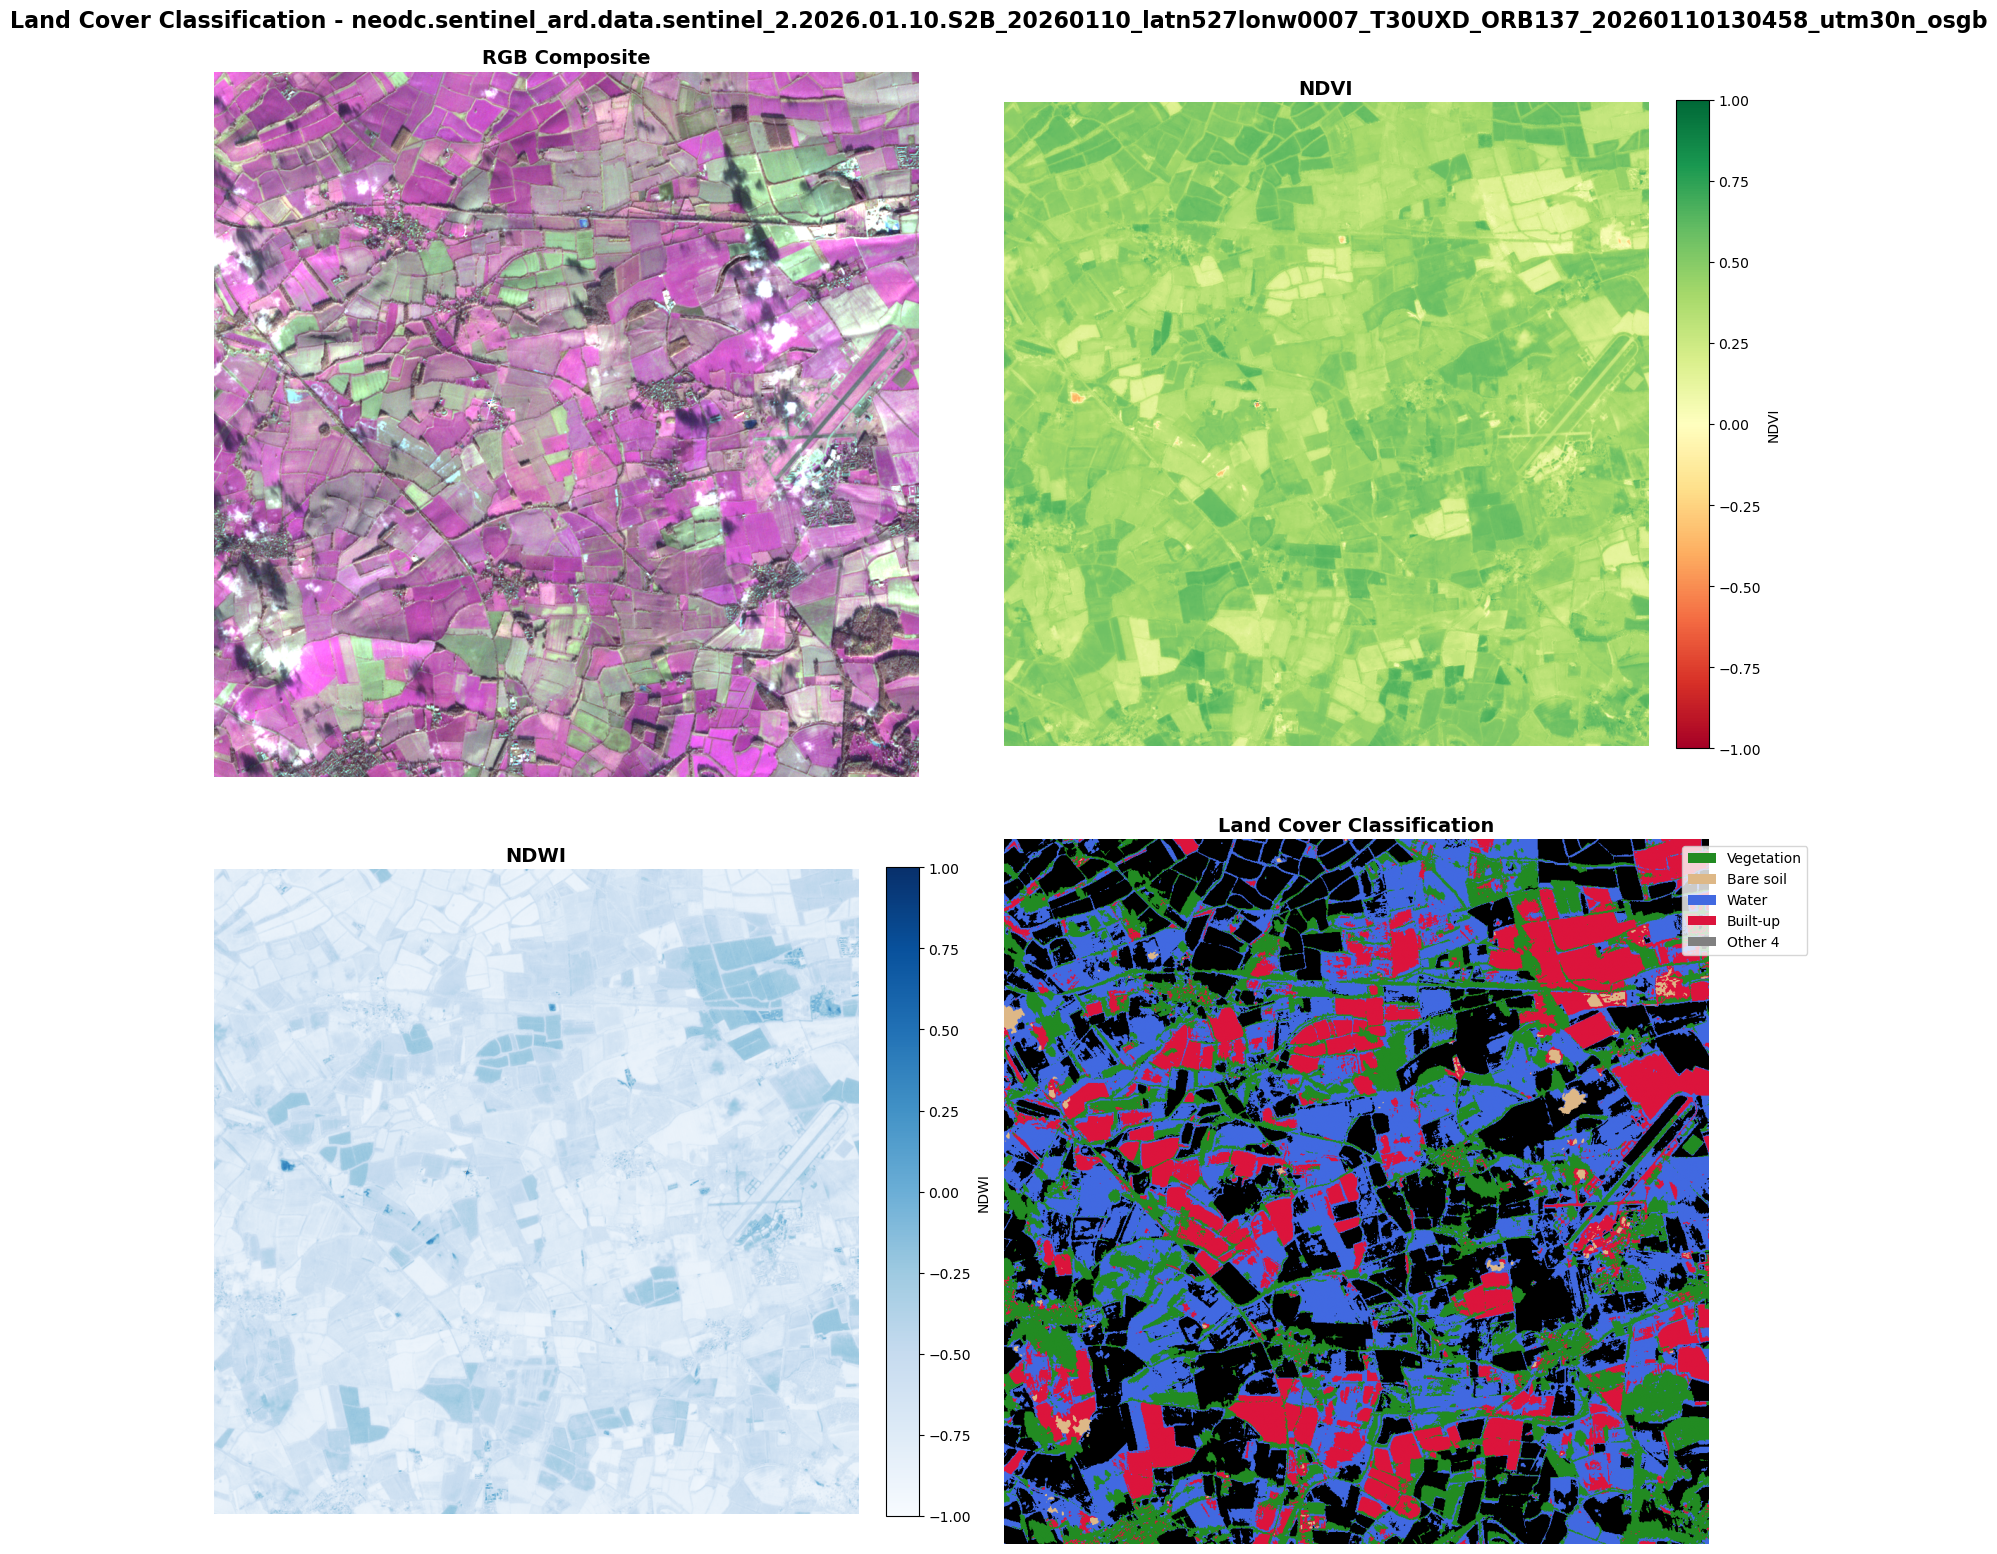


Classification Statistics:
  Vegetation: 304,517 pixels (30.45%)
  Bare soil: 210,692 pixels (21.07%)
  Water: 5,697 pixels (0.57%)
  Built-up: 319,577 pixels (31.96%)
  Other 4: 159,512 pixels (15.95%)

Visualization complete!


In [12]:
# Create RGB composite (normalized)
rgb_composite = np.stack(
    [
        np.clip(red_data / np.percentile(red_data, 98), 0, 1),
        np.clip(green_data / np.percentile(green_data, 98), 0, 1),
        np.clip(blue_data / np.percentile(blue_data, 98), 0, 1),
    ],
    axis=-1,
)

# Define colors for classes
class_colors = {
    "Water": "#4169E1",  # Royal blue
    "Vegetation": "#228B22",  # Forest green
    "Built-up": "#DC143C",  # Crimson
    "Bare soil": "#DEB887",  # Burlywood
    "Other": "#808080",  # Gray
}

# Create colormap for classification
colors_list = []
for cls in range(num_classes):
    label = class_mapping[cls]
    if "Water" in label:
        colors_list.append(class_colors["Water"])
    elif "Vegetation" in label:
        colors_list.append(class_colors["Vegetation"])
    elif "Built-up" in label:
        colors_list.append(class_colors["Built-up"])
    elif "Bare soil" in label:
        colors_list.append(class_colors["Bare soil"])
    else:
        colors_list.append(class_colors["Other"])

# Add color for unclassified (-1)
colors_list.insert(0, "#000000")
cmap_class = ListedColormap(colors_list)

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 16))

# RGB Composite
axes[0, 0].imshow(rgb_composite)
axes[0, 0].set_title("RGB Composite", fontsize=14, fontweight="bold")
axes[0, 0].axis("off")

# NDVI
im1 = axes[0, 1].imshow(ndvi, cmap="RdYlGn", vmin=-1, vmax=1)
axes[0, 1].set_title("NDVI", fontsize=14, fontweight="bold")
axes[0, 1].axis("off")
plt.colorbar(im1, ax=axes[0, 1], fraction=0.046, pad=0.04, label="NDVI")

# NDWI
im2 = axes[1, 0].imshow(ndwi, cmap="Blues", vmin=-1, vmax=1)
axes[1, 0].set_title("NDWI", fontsize=14, fontweight="bold")
axes[1, 0].axis("off")
plt.colorbar(im2, ax=axes[1, 0], fraction=0.046, pad=0.04, label="NDWI")

# Classification Map
classification_display = classification.copy()
classification_display[classification == -1] = num_classes  # Map -1 to last color index
im3 = axes[1, 1].imshow(
    classification_display, cmap=cmap_class, vmin=0, vmax=num_classes
)
axes[1, 1].set_title("Land Cover Classification", fontsize=14, fontweight="bold")
axes[1, 1].axis("off")

# Create legend
from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor=colors_list[cls + 1], label=class_mapping[cls])
    for cls in range(num_classes)
]
axes[1, 1].legend(handles=legend_elements, loc="upper right", bbox_to_anchor=(1.15, 1))

plt.suptitle(
    f"Land Cover Classification - {item.id}", fontsize=16, fontweight="bold", y=0.98
)
plt.tight_layout()
plt.show()

# Print class statistics
print("\nClassification Statistics:")
total_pixels = height * width
for cls in range(num_classes):
    count = np.sum(classification == cls)
    percentage = (count / total_pixels) * 100
    print(f"  {class_mapping[cls]}: {count:,} pixels ({percentage:.2f}%)")

print("\nVisualization complete!")

## Summary

This notebook has successfully:

1. ✅ Loaded the STAC item from: `{{STAC_ITEM_LINK}}`
2. ✅ Determined area of interest (AOI or default window)
3. ✅ Accessed multiple Sentinel-2 bands (Blue, Green, Red, NIR)
4. ✅ Calculated spectral indices (NDVI, NDWI)
5. ✅ Prepared features for classification
6. ✅ Performed K-means clustering
7. ✅ Automatically labeled classes based on spectral characteristics
8. ✅ Visualized the classification results

### Next Steps

You can now:
- Export the classification results as a GeoTIFF
- Perform accuracy assessment with ground truth data
- Compare classifications across different dates
- Adjust the number of classes for different levels of detail
- Apply post-processing (smoothing, majority filtering)

### Resources

- **Collection**: {{STAC_COLLECTION_NAME}}
---

*This notebook was automatically generated from a template and configured with your selected dataset.*